<a href="https://colab.research.google.com/github/HolaBaGa/tibame/blob/main/%E7%88%AC%E8%9F%B2%E6%8A%93%E5%8B%95%E7%95%AB%E7%98%8B%E5%BD%88%E5%B9%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

5/16 影片 2:20:38 開始

### 目標: 利用 csv, json , html格式, 配合彈幕找到html 超連結, 再下載

# 使用 urllib.request 內建用來開啟 URLs 的可擴充函式庫

In [ ]:
import urllib.request as req
# urllib.request 是內建用來開啟 URLs 的可擴充函式庫
# list + duct: JSON格式

url = "https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47221&geo=TW%2CHK"
f = req.urlopen(url)
# 送出網址
content = f.read()
# 讀取網址
print(content)
# 印出網址, 遠端開啟的概念
# 輸出後的\u8b9a\ 是萬國碼(Unicode)表示的中文

print(type(content))
# 確認型態, 輸出 'bytes'為 0與1的組合, 可當成原始字串, 字典外面會寫b做提示
# 輸出後的 \u 開頭是Unicode 編碼（萬國編碼）代表原始內容是中文

python語法

動詞+s 表示為字串, 中文叫load的字串

參數+s 也是為字串

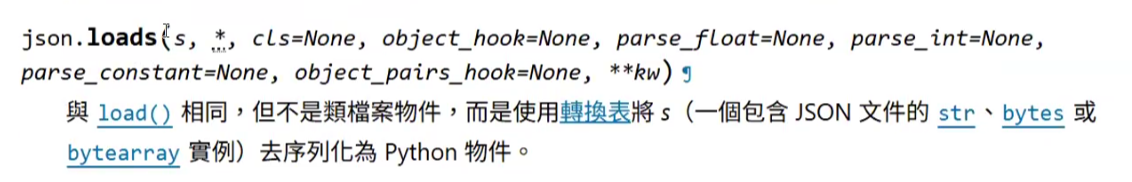

In [ ]:
# 本欄重點, 確認型態是否有轉換, 輸出從萬國碼改為字典

import json
import urllib.request as req

url = "https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47221&geo=TW%2CHK"
f = req.urlopen(url)
content = f.read()
print(type(content))
print(content)
content = json.loads(content)
# json.loads python 型態轉換的語法

print(type(content))
print(content)


In [ ]:
# 本欄重點, 拿到條列式的彈幕

import json
import urllib.request as req

url = "https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47221&geo=TW%2CHK"
f = req.urlopen(url)
content = f.read()
content = json.loads(content)
# content 字典

danmus = content["data"]["danmu"]
# 拿出字典中 ["data"], ["danmu"]的清單
for d in danmus:
# 從 danmus 清單中拿出一個彈幕字典，並把這個字典暫時命名為 d
    print(d["userid"], d["text"])
    # 印出d的id(字典的key),d的文字(字典的key)
    # 迴圈把資料「拆包」，逐一取出並自動換行，變成乾淨、好讀的格式


格式彙整!!!

JSON格式: [] + {}
CSV標準表格格式
HTML格式

CSV(Comma-Separated Values)
CSV標準表格格式 (用"," 分隔每一個值, 留意逗號/換行/雙引號的用法)
* 攣生兄弟: TSV (用TAB分隔每一個值)

CSV範例

姓名,身高

Elwing,175

"Bob, Mr. Chou",180

注意:
* execel 不要用, 因不是用萬國編碼, 建議用google sheet (萬國編碼utf-8 )
這樣不論蘋果或是 Linux  都可以正常使用
而365出是為了解決編碼的問題
* 大五碼 (Big5)最普及的繁體中文字元集標準，主要使用於台灣、香港與澳門
* GBK 編碼 簡體中文

```
HTML格式: 無數個長方形區塊所構成
<> 開始

</> 結束

超連結
<a href="網址">
    請點我
</a>


1. 名字: 決定他是什麼
a: 超連結, img: 圖片, video: 影片

2. 屬性: 決定細節(key="value")
a href="網址"  -> 超連結連到外面, 所以是Hypertext Reference
img video src="網址" -> 把網址的東西載到現在的頁面

3. 顯示的內容

下圖範例解釋
<.....> 開始
a 名字超連結
href= ... 47429 : 屬性
32 : 內容
</a> 結束
```



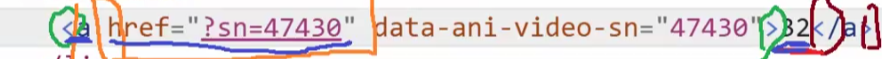

# csv教學

In [1]:
# 生成一個.csv的檔案
# 一般寫法, 最後要寫colse, 與高級寫法各有各的好

f = open("test.csv", "w", encoding="utf-8")
# "w" 表示寫入
# 打開叫f

f.write("姓名,身高\n")
#  "\"逃脫字元+"n" = \n表示換行,不能用enter會變成編輯器的換行
f.write("Elwing,175\n")
f.write('"Bob,Mr.Chou",180')
# 注意'跟"用法, 如果字串裡面一定要有""雙引號, 外面就要用''單引號, 作定義字串
# 最後結尾不用換行
f.close()

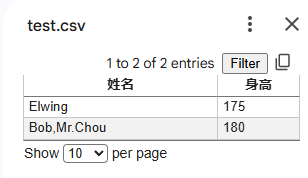

In [ ]:
# 高級寫法
# with as: 會自動幫你close
with open("test.csv", "w", encoding="utf-8") as f:
    f.write("姓名,身高\n")
    f.write("Elwing,175\n")
    f.write('"Bob,Mr.Chou",180')

# 銜接 csv

In [ ]:
import json
import urllib.request as req
import pandas as pd
# as 後面的名稱是淺規則, 大家都這樣說, 如果沒有寫, 其他人會運行錯誤
# colab 會自動安裝常用的第三方程式, 如果剛好沒有, 使用!pip install pandas , !表命令列指令
# pandas 表格很好用
# !是跳脫python, 使用終端機

# list + dict: JSON格式
url = "https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47221&geo=TW%2CHK"
f = req.urlopen(url)
content = f.read()
content = json.loads(content)

danmus = content["data"]["danmu"]
# for d in danmus:
#     print(d["userid"], d["text"])
# []+{} -> DataFrame(pandas自訂義的表格型態), pandas專屬功能
df = pd.DataFrame(danmus)
df.to_csv("baha.csv", encoding="utf-8")
# encoding="utf-8", 後面接index=False 表示不須存列標籤, 就是開頭的0123..
df.to_excel("baha.xlsx")
# 後面不用encoding, 因為execel不是萬國編碼
df

,text,color,size,position,time,sn,userid
0,讚阿XD,#FFFFFF,1,0,0,47806325,j11161984
1,悲報，距離完結還有9集,#FDE53D,1,0,0,47808838,BENNY319
2,巴哈我大哥,#FFFFFF,1,0,0,47812257,milk2009
3,簽 hiro,#0036FA,1,2,0,47840473,andyhiro
4,2026/01/22 簽~,#00C3FC,1,0,0,47866460,joe871114
...,...,...,...,...,...,...,...
2996,現實是會沖倒暗河而沿水脈而歸,#FFFFFF,1,0,14400,47828222,z999999op
2997,超級帥的大叔,#FFFFFF,1,0,14400,47835270,Jacschnapps
2998,2026.1.21 *,#FFFFFF,1,0,14400,47856058,s935602
2999,天啊！！！下一集就是南之勇者啦！！！,#FFFFFF,1,0,14400,47858790,khst9021735


# 定義函式

In [2]:
import json
import os
import urllib.request as req
import pandas as pd

def get_danmu(sn, dn, chapter=-1):
    if not os.path.exists(dn):
        os.makedirs(dn)
    # list + dict: JSON格式
    url = f"https://api.gamer.com.tw/anime/v1/danmu.php?videoSn={sn}&geo=TW%2CHK"
    print("下載:", url)
    f = req.urlopen(url)
    content = f.read()
    content = json.loads(content)
    danmus = content["data"]["danmu"]

    df = pd.DataFrame(danmus)
    df["ch"] = chapter #增加一行集數
    df.to_csv(f"{dn}/{sn}.csv", encoding="utf-8")
    return df

get_danmu("47221", "baha/芙莉蓮", 30)

下載: https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47221&geo=TW%2CHK


,text,color,size,position,time,sn,userid,ch
0,讚阿XD,#FFFFFF,1,0,0,47806325,j11161984,30
1,悲報，距離完結還有9集,#FDE53D,1,0,0,47808838,BENNY319,30
2,巴哈我大哥,#FFFFFF,1,0,0,47812257,milk2009,30
3,簽 hiro,#0036FA,1,2,0,47840473,andyhiro,30
4,2026/01/22 簽~,#00C3FC,1,0,0,47866460,joe871114,30
...,...,...,...,...,...,...,...,...
2996,現實是會沖倒暗河而沿水脈而歸,#FFFFFF,1,0,14400,47828222,z999999op,30
2997,超級帥的大叔,#FFFFFF,1,0,14400,47835270,Jacschnapps,30
2998,2026.1.21 *,#FFFFFF,1,0,14400,47856058,s935602,30
2999,天啊！！！下一集就是南之勇者啦！！！,#FFFFFF,1,0,14400,47858790,khst9021735,30


# 練習語法
## 常見的應用場景批處理檔案：
## 在迴圈中更換數字，自動生成 1-100.csv、101-200.csv 等大量檔案。
## 自動化命名：根據當天日期或使用者 ID 生成專屬的報告名稱。

In [ ]:
sn = 100
sn2 = 300
s = str(sn) + "-" + str(sn2) + ".csv"
# format string, 字串專屬功能
s = "{}-{}.csv".format(sn, sn2)
# sn對第一個大括號, sn2對第二個大括號
# 準備一個字串, 可以用很多次

# 如果只用這一次
s = f"{sn}-{sn2}.csv"
s

'100-300.csv'

## 資料夾位置都用"/", 不要用到跳脫字元 `"\"`  

In [ ]:
# urllib.request --- 用來開啟 URLs 的可擴充函式庫
# os 作業系統介面模組, 資料夾管理, 用程式開資料夾非常常使用
# pandas 用於處理與分析表格資料

import json
import os
import urllib.request as req
import pandas as pd

serials = ["47221", "47428", "47429"]
# 如果資料夾不存在, 就創造起來
#  os.path.exists 專門負責路徑
dn = "baha/芙莉蓮"
if not os.path.exists(dn):
    os.makedirs(dn)
    # os.makedirs 建立目錄(複數s)


for sn in serials:
    print("序號:", sn)
    # list + dict: JSON格式
    url = "https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47221&geo=TW%2CHK"
    f = req.urlopen(url)
    content = f.read()
    content = json.loads(content)

    danmus = content["data"]["danmu"]
    # for d in danmus:
    #     print(d["userid"], d["text"])
    # []+{} -> DataFrame(pandas自訂義的表格型態)
    df = pd.DataFrame(danmus)
    # index=False: 不須存列標籤
    df.to_csv(f"{dn}/{sn}.csv", encoding="utf-8")
    # df.to_excel("baha.xlsx")
    df

序號: 47221
序號: 47428
序號: 47429


## 先找原始碼, 是否有集數"47221", "47428", "47429" , 裡面要有每一集的超連結, 才是我們要的網址 (url)

## 網址? 後面是參數, 如下圖所示

#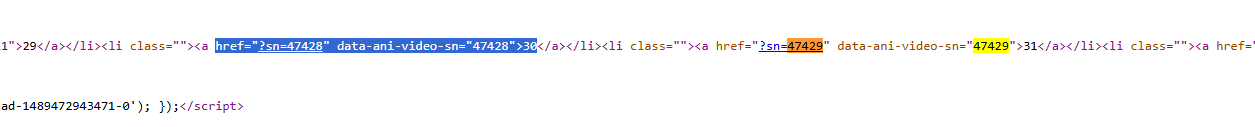

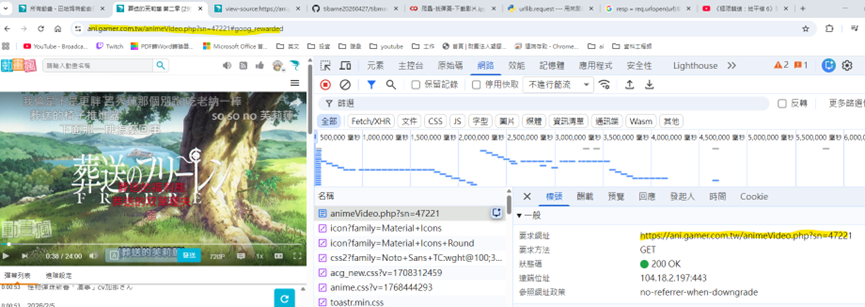

In [ ]:
# 錯誤範例

import urllib.request as req
url = "https://ani.gamer.com.tw/animeVideo.php?sn=47221"
resp = req.urlopen(url)
content = resp.read()
print(content)

# 回傳HTTP Error 403: Forbidden 因為沒有放入信封,

HTTPError: HTTP Error 403: Forbidden

如果回傳 HTTPError:  **HTTP Error 403: Forbidden**
最常被檢查
**要求標頭的 user-agent**

有時候:
- referrer 上一頁的版本
- accept-language: 例如goole 針對不同地區給予不同的首頁


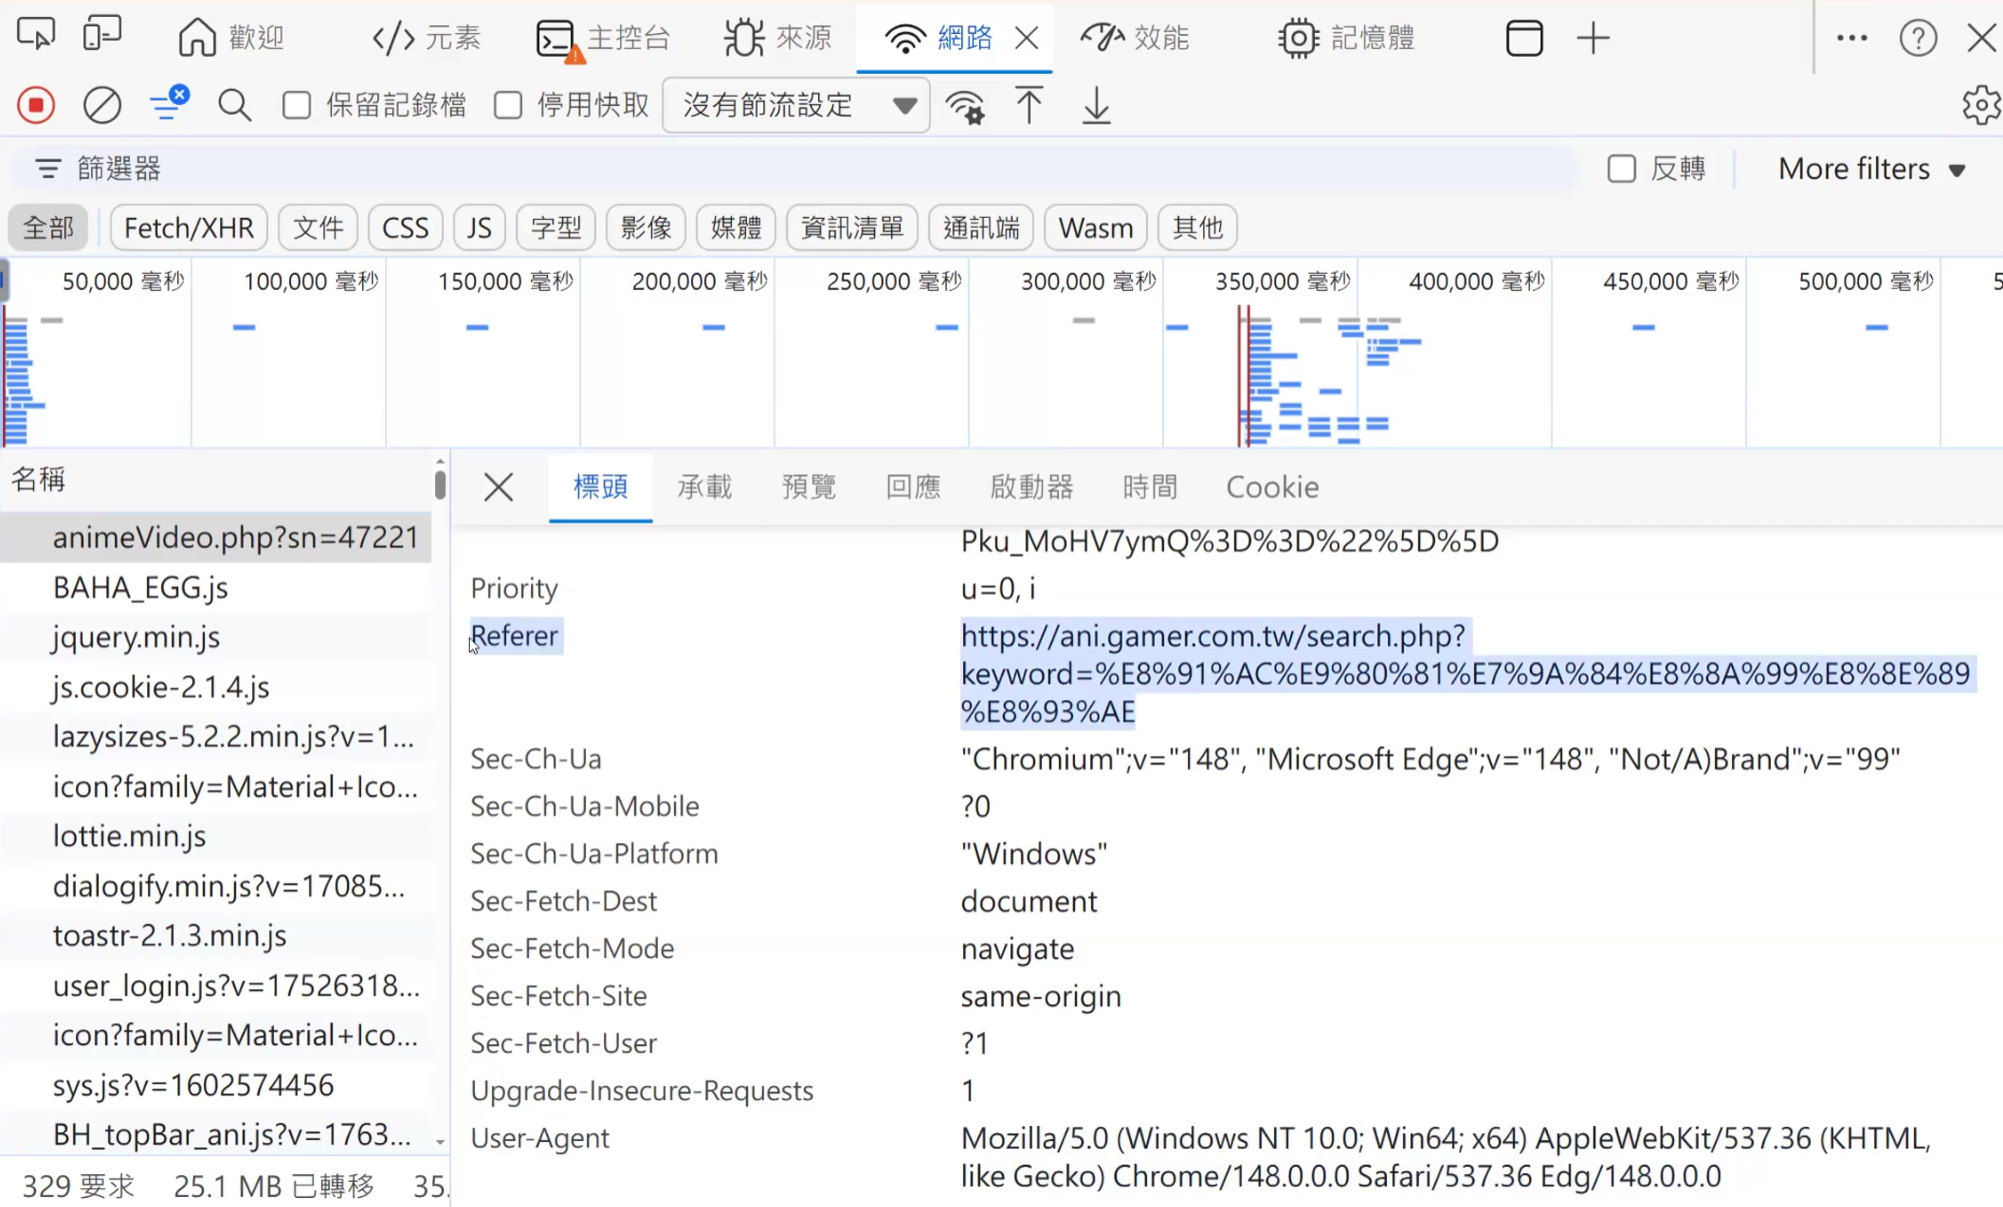

In [ ]:
# HTTP狀態碼的開頭
# 2: 成功
# 3: 轉址
# 4: 錯誤
# 404: Not Found
# 403: Forbidden
# 1. IP ban: 很肆無忌憚過
# 2. 人家覺得你不是瀏覽器(妳跟瀏覽器送出的不一樣=Headers沒加完)
# 問題: 網址+信封(headers)
# 回應: 回復+信封(headers)
# 以下丟到pycharm執行, baha的動畫首頁是有封鎖海外ip的
import urllib.request as req
url = "https://ani.gamer.com.tw/animeVideo.php?sn=47221"

h = {
    "User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/148.0.0.0 Safari/537.36 Edg/148.0.0.0"
}
r = req.Request(url, headers=h)
resp = req.urlopen(r)
content = resp.read()
print(content)

# colab 只能單獨下載, 若要打包帶走使用 !zip

In [ ]:
#原始程式!zip -r /content/file.zip /content/Folder_To_Zip

# if 妳要下載整個資料夾
!zip -r /content/danmu.zip /content/baha
# 壓縮到content/file.zip, 對象是content/baha 資料夾
# 之所以是content 開頭是因為colab 原始是存在content資料夾底下

# if 妳要直接存google drive
get_danmu("47221", "/content/drive/MyDrive/芙莉蓮")
# 程式執行建好之後, 不能手動操作, 一定要放在資料夾, 不然資料會散落各處, 就要寫程式移除

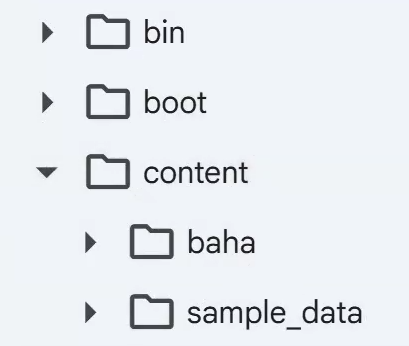

# 重要!!
## Beautifulsoup4 (bs4)專屬功能 HTML 解析 (可解決大部分問題)

## 1. find/find_all (html名字, 篩選條件)
- find 找第一個
- find all 找全部
## 2. 屬性: [屬性名稱]  文字: .get_text()
- 當你拿到妳需要的區塊時候
## 3. .startswith()
- 從某個地方開始, 使用bs4 專屬功能.startswith(), 從?sn開始

In [3]:
# 組合 (最終型態, 成功下載29-38集彈幕)
import urllib.request as req
# Beautifulsoup4 可以直接打bs4
import bs4 as bs

# url = "https://ani.gamer.com.tw/animeVideo.php?sn=47221"
# 因為colab, 動畫瘋封鎖海外ip, 把F12 資訊都先複製到GITHUB中
url = "https://github.com/Elwing-Chou/tibame20260427/raw/refs/heads/main/%E8%8A%99%E8%8E%89%E8%93%AE.html"

h = {
    "User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/148.0.0.0 Safari/537.36 Edg/148.0.0.0"
}
r = req.Request(url, headers=h)
resp = req.urlopen(r)
content = resp.read()

dn = "baha/芙莉蓮"
# 這裡的動作就跟上面的json.loads依樣 是bytes型態轉換成bs 裡自定義區塊型態
html = bs.BeautifulSoup(content)
# 區塊專屬功能: find/find_all(html名字, 篩選條件)
for a in html.find_all("a"):
    # 當你拿到妳需要的區塊時候, 屬性: [屬性名稱]  文字: .get_text()
    a_href = a["href"]
    a_text = a.get_text()
    # 從某個地方開始, 使用bs4 專屬功能.startswith(裡面放關鍵字的開頭)
    if a_href.startswith("?sn"):
        print(a_text, a_href)
        sn = a_href.split("=")[1]  # href.split()做分割
        get_danmu(sn, dn, a_text)

# 取資料跟整理資料不要一起做, 萬一有問題, 連帶影響全部的資料

29 ?sn=47221
下載: https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47221&geo=TW%2CHK
30 ?sn=47428
下載: https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47428&geo=TW%2CHK
31 ?sn=47429
下載: https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47429&geo=TW%2CHK
32 ?sn=47430
下載: https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47430&geo=TW%2CHK
33 ?sn=47567
下載: https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47567&geo=TW%2CHK
34 ?sn=47737
下載: https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47737&geo=TW%2CHK
35 ?sn=47915
下載: https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47915&geo=TW%2CHK
36 ?sn=47916
下載: https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47916&geo=TW%2CHK
37 ?sn=48126
下載: https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=48126&geo=TW%2CHK
38 ?sn=48127
下載: https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=48127&geo=TW%2CHK


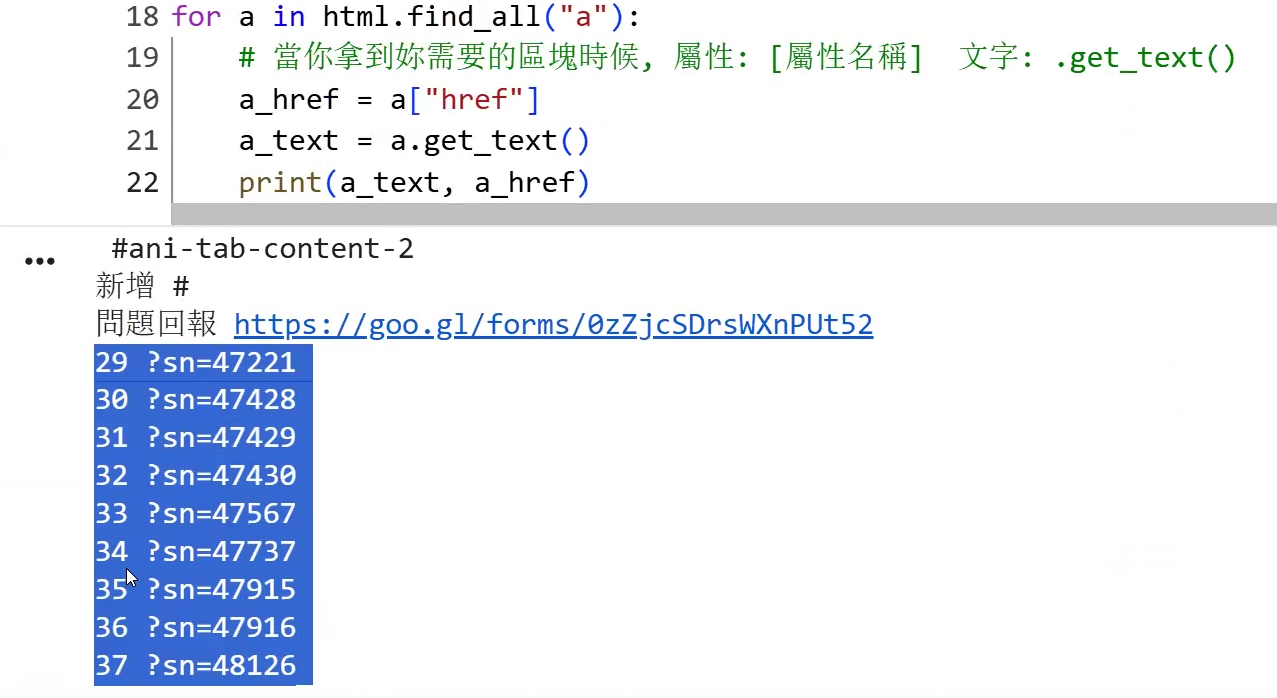

如果要從github 拿資料, 進到要拿的頁面後, Raw位置按右鍵複製連結網址, 就可以只拿到裡面的資料而不是github的頁面

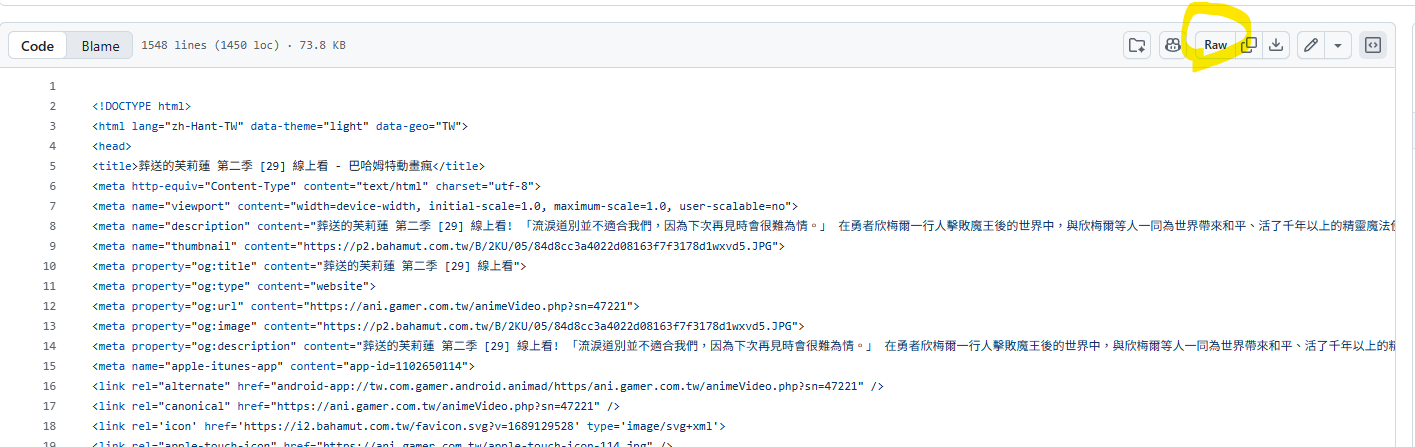

# pandas 語法
## 1. 行操作
- 單行操作
- 多行操作
- 增加一行

In [ ]:
# pandas 語法, 表格操作
# 行操作
df = get_danmu("47221", "baha/芙莉蓮", 29)
# 單行
df["text"]

# 多行
cols = ["text", "userid"]
df[cols]  # 查詢清單

# 增加新一行(同一個預設值)
df["new"] = 20
df

下載: https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47221&geo=TW%2CHK


,text,color,size,position,time,sn,userid,ch,new
0,讚阿XD,#FFFFFF,1,0,0,47806325,j11161984,29,20
1,悲報，距離完結還有9集,#FDE53D,1,0,0,47808838,BENNY319,29,20
2,巴哈我大哥,#FFFFFF,1,0,0,47812257,milk2009,29,20
3,簽 hiro,#0036FA,1,2,0,47840473,andyhiro,29,20
4,2026/01/22 簽~,#00C3FC,1,0,0,47866460,joe871114,29,20
...,...,...,...,...,...,...,...,...,...
2996,現實是會沖倒暗河而沿水脈而歸,#FFFFFF,1,0,14400,47828222,z999999op,29,20
2997,超級帥的大叔,#FFFFFF,1,0,14400,47835270,Jacschnapps,29,20
2998,2026.1.21 *,#FFFFFF,1,0,14400,47856058,s935602,29,20
2999,天啊！！！下一集就是南之勇者啦！！！,#FFFFFF,1,0,14400,47858790,khst9021735,29,20


## 整理資料
### 目標: 把某個人在19-38集的貼文整理出來

In [ ]:
# pandas兩大操作
# 1. 過濾: df[查詢帶入跟資料筆數一樣多的True/False] True:留下 False:刪去
# 2. 轉換:

# 過濾 (絕對要會)
df = get_danmu("47221", "baha/芙莉蓮", 29)
test_df = df.head(3) # 取三筆
fil = [True, False, True] # 準備1個清單, 其中第1筆資料不要
test_df[fil] # 查詢清單, 印出第0, 2筆資料

下載: https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47221&geo=TW%2CHK


,text,color,size,position,time,sn,userid,ch
0,讚阿XD,#FFFFFF,1,0,0,47806325,j11161984,29
2,巴哈我大哥,#FFFFFF,1,0,0,47812257,milk2009,29


In [ ]:
# pandas 讀取語法
# 如果有存列標籤, 要加index_col=0, 告知第0行是我的列標籤, 不然會有二行列標籤

pd.read_csv("/content/baha/芙莉蓮/47221.csv", encoding="utf-8", index_col=0)

In [ ]:
# glob.glob 語法 一定要會
# ()內表示找出baha資料夾底下, 裡面的任意資料夾, 任意 .csv的副檔名

glob.glob("baha/*/*.csv"):

In [7]:
# 本欄重點 結合一個大表 (concat的功能 知道就好)

import glob
import pandas as pd

total = []
for fn in glob.glob("baha/*/*.csv"):
    df = pd.read_csv(fn, encoding="utf-8", index_col=0)
    total.append(df)

# 專屬功能 sort_values(by="ch") 排序依照ch, 其他會維持不動
# 也可以多重排序, 例如以集數先排序, 再以時間排序(by=["ch", "time"])
# df = df.reset_index(drop=True) 重製排序, drop=True 把舊的移除, 如果不寫, 會靶新舊都列出來
df = pd.concat(total)
df = df.sort_values(by="ch")
df = df.reset_index(drop=True)
df


,text,color,size,position,time,sn,userid,ch
0,暫停看閃避,#FFFFFF,1,0,7207,48106146,aesopw64883,29
1,洗環 喜歡?,#FFFFFF,1,0,8462,48046780,kuo850214111,29
2,簽!,#FFFFFF,1,0,23,47875875,megaman1206,29
3,ED>OP,#FFFFFF,1,0,14366,47816826,Laho123,29
4,歡迎來到德瑪西亞,#FFFFFF,1,0,3147,47816563,Laho123,29
...,...,...,...,...,...,...,...,...
50839,有噎,#FFFFFF,1,0,1792,48592324,k811119s,38
50840,2026/05/27紀念,#FFFFFF,1,0,13007,49288399,i911206,38
50841,那個傘電有聲音 直接戳爆我笑點ww,#FFFFFF,1,0,2240,48589219,GrandFish21,38
50842,黃金鄉篇 明年十月,#FFFFFF,1,0,0,48589151,Sty7251,38


### value_counts()和 unique() 語法, 差不多用途, 只差在呈現方式

In [ ]:
# 詳答

print(df["userid"].value_counts())

userid
edward103262    628
jacket50820     572
cindyrexwong    362
sunny5512373    352
updp10547789    280
               ... 
rainfish0703      2
shining1202       2
Julie960925       2
silverx           2
sqn9dgnn6n        2
Name: count, Length: 7523, dtype: int64


In [9]:
# 簡答版, 不會按照筆數多寡排序

print(df["userid"].unique())

['aesopw64883' 'kuo850214111' 'megaman1206' ... 'linss8866' 'black61101'
 'siaoooochen']


In [10]:
# pandas 會對每一格做一樣事情, 可以對每一格做+-法, 每一格做判斷

uids = df["userid"].unique()
df['userid'] == uids[0]

,userid
0,True
1,False
2,False
3,False
4,False
...,...
50839,False
50840,False
50841,False
50842,False


In [12]:
# 抓出第0個人發出的彈幕

uids = df["userid"].unique()
fil = df['userid'] == uids[0]
df[fil]

,text,color,size,position,time,sn,userid,ch
0,暫停看閃避,#FFFFFF,1,0,7207,48106146,aesopw64883,29
4260,暫停看閃避,#FFFFFF,1,0,7207,48106146,aesopw64883,29
20676,"木頭很正常好嗎,我30歲還沒交往過QAQ",#FFFFFF,1,0,4552,48106322,aesopw64883,32
21642,如果福利蓮的能出個online game就好了,#FFFFFF,1,0,7978,48106339,aesopw64883,32
21643,"不過這年代,會玩PC的人也已經越來越少了QAQ",#FFFFFF,1,0,7978,48106343,aesopw64883,32
22926,如果福利蓮的能出個online game就好了,#FFFFFF,1,0,7978,48106339,aesopw64883,32
22927,"不過這年代,會玩PC的人也已經越來越少了QAQ",#FFFFFF,1,0,7978,48106343,aesopw64883,32
22928,"木頭很正常好嗎,我30歲還沒交往過QAQ",#FFFFFF,1,0,4552,48106322,aesopw64883,32
35509,"這一話太精彩了,害我一直重復看",#FFFFFF,1,0,11,48546708,aesopw64883,36
35510,福利蓮最讚的一話,#FFFFFF,1,0,56,48546714,aesopw64883,36


### 組合語法, 抓出所有人發出的彈幕

In [5]:
# 開啟資料夾, 沒有就新增
import os
dn = "baha/processed"
if not os.path.exists(dn):
    os.makedirs(dn)

# value_counts()和 unique() 差不多用途
uids = df["userid"].unique()
for u in uids:
    # print(u) 檢查用, 確認走過哪個id做存檔
    # !!! 過濾步驟
    fil = df["userid"] == u  # 準備跟資料筆數差不多的T/F
    fp = f"{dn}/{u}.csv"  # 設定存檔檔名
    df[fil].to_csv(fp, encoding="utf-8") # 帶入 df[fil]完成過濾